# FitzHugh–Nagumo model (ODE) solved with time-marching PINNs (JAX + SSBroyden)

Same problem as `FitzHugh-Nagumo-RK45.ipynb`:

$$
\frac{dv}{dt} = v - \frac{v^3}{3} - w + I_{\text{ext}}, \qquad
\frac{dw}{dt} = \frac{1}{\tau}\,\big(v + a - b\,w\big), \qquad
v(t_0)=v_0,\; w(t_0)=w_0 .
$$

JAX port of `FitzHugh-Nagumo-PINN-torch.ipynb`, with the same windows, network and loss. The
difference is the optimiser: instead of Adam + L-BFGS in float32, each window is trained with
**SSBroyden** (self-scaled Broyden quasi-Newton with Zoom line search, from
[`ssbroyden_optimistix`](https://github.com/IvanBioli/ssbroyden_jax)) in float64.
The networks are trained only on the ODE residual (no solution data). The RK45 solution is used
purely for validation.

### Why time-marching?

The equilibrium $(v^*, w^*) \approx (-0.80, -0.13)$ is a *weakly* unstable focus. A single network
on a long interval tends to converge to a trajectory that approaches this equilibrium: it has a small
residual but misses the spikes. `FitzHugh-Nagumo-PINNs-jax.ipynb` (one network, growing window) works
on $[0, 50]$ but fails on $[0, 100]$.

Instead, $[t_0, t_{\text{final}}]$ is split into windows $[t_k, t_{k+1}]$. Window $k$ has its own
small MLP, and its initial condition is the end state of window $k-1$.

Run with the **`optimistix_env`** kernel.

## Parameters (edit here)

In [1]:
# ---------------- ODE parameters (same as the RK45 notebook) ----------------
a     = 0.7     # recovery offset
b     = 0.8     # recovery damping
tau   = 12.5    # time-scale separation (w is slower for larger tau)
I_ext = 0.5     # external stimulus current

# ---------------- Initial conditions ----------------
v0 = -1.0
w0 = 1.0

# ---------------- Time interval ----------------
t0      = 0.0
t_final = 100.0
n_eval  = 4000     # output grid for plots / comparison

# ---------------- Time-marching PINN settings (same as the torch notebook) ----------------
window_length = 10.0   # length of each time window
n_colloc      = 400    # collocation points per window (uniform grid)
hidden_layers = 3
hidden_width  = 32
seed          = 0

# ---------------- SSBroyden settings ----------------
maxiter_window = 3000    # SSBroyden iterations per window (torch: lbfgs_max_iter = 3000)
rtol = atol    = 1e-14   # solver tolerances

## Imports and setup

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"   # GPU to use ("0" or "1"); set before importing jax

import sys
import time

# ssbroyden_optimistix is not a package: add its folder to the path
sys.path.insert(0, "/home/pmzib/ssbroyden_optimistix")

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jax import random, vmap
from scipy.integrate import solve_ivp

from optimistix_wrapper import run_optimization
from ssbrodyen_family import SSBroyden, Zoom

jax.config.update("jax_enable_x64", True)   # quasi-Newton methods need double precision
print("JAX devices:", jax.devices())

JAX devices: [CudaDevice(id=0)]


## Model

Inside window $[t_a, t_b]$, with $s = (t - t_a)/(t_b - t_a) \in [0, 1]$,

$$
\big(v, w\big)(t) = \big(v_a, w_a\big) + s\,\mathcal{N}_\theta(2s - 1),
$$

so the initial condition of each window (and continuity between windows) holds exactly.
The loss is the mean squared ODE residual on a uniform grid, with the $w$-equation
multiplied by $\tau$ so both residuals are $O(1)$:

$$
\mathcal{L} = \frac{1}{N}\sum_i \Big(\dot v - v + \tfrac{v^3}{3} + w - I_{\text{ext}}\Big)^2
+ \Big(\tau \dot w - v - a + b w\Big)^2 .
$$

All windows use the same architecture, so their parameters share a single `static` part.
Weights are Xavier-normal and biases are zero, as in the torch notebook.

In [3]:
class MLP(eqx.Module):
    layers: list

    def __init__(self, layer_sizes, *, key):
        keys = random.split(key, len(layer_sizes) - 1)
        layers = []
        for n_in, n_out, k in zip(layer_sizes[:-1], layer_sizes[1:], keys):
            linear = eqx.nn.Linear(n_in, n_out, key=k)
            std = np.sqrt(2.0 / (n_in + n_out))   # Xavier normal
            linear = eqx.tree_at(lambda l: (l.weight, l.bias), linear,
                                 (std * random.normal(k, (n_out, n_in)), jnp.zeros(n_out)))
            layers.append(linear)
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers[:-1]:
            x = jnp.tanh(layer(x))
        return self.layers[-1](x)


layer_sizes = [1] + [hidden_width] * hidden_layers + [2]
_params, static = eqx.partition(MLP(layer_sizes, key=random.PRNGKey(seed)), eqx.is_array)
n_params = sum(p.size for p in jax.tree_util.tree_leaves(_params))


def u(params, t, t_a, t_b, y_a):
    # PINN solution (v, w) at scalar time t inside window [t_a, t_b], starting from y_a.
    s = (t - t_a) / (t_b - t_a)
    nn = eqx.combine(params, static)
    return y_a + s * nn(jnp.atleast_1d(2.0 * s - 1.0))


def residual(params, t, t_a, t_b, y_a):
    # ODE residuals (r_v, r_w) at scalar time t, w-equation scaled by tau.
    uu, du_dt = jax.jvp(lambda tt: u(params, tt, t_a, t_b, y_a), (t,), (1.0,))
    v, w = uu
    dv, dw = du_dt
    return jnp.array([dv - (v - v**3 / 3.0 - w + I_ext),
                      tau * dw - (v + a - b * w)])


v_u        = jax.jit(vmap(u, (None, 0, None, None, None)))
v_residual = vmap(residual, (None, 0, None, None, None))


def make_loss(t_col, t_a, t_b, y_a):
    def loss(params):
        return jnp.mean(jnp.sum(v_residual(params, t_col, t_a, t_b, y_a) ** 2, axis=1))
    return loss


print(f"Trainable parameters per window: {n_params}")

Trainable parameters per window: 2242


## Train window by window (SSBroyden)

The network of each window is initialised with its own key. The loss history (logged at every
accepted SSBroyden step) is kept per window.

In [4]:
def train_window(t_a, t_b, y_a, key):
    params0, _ = eqx.partition(MLP(layer_sizes, key=key), eqx.is_array)
    t_col = jnp.linspace(t_a, t_b, n_colloc)
    loss = make_loss(t_col, t_a, t_b, y_a)
    history = [float(loss(params0))]

    def callback(it, p, state, cur_loss):
        history.append(cur_loss)
        return False

    solver = SSBroyden(rtol=rtol, atol=atol, search=Zoom(initial_guess_strategy="increase"))
    res = run_optimization(solver, loss, params0, maxiter=maxiter_window,
                           callback=callback, verbose=False)
    return res.params, history


edges = np.arange(t0, t_final + 1e-9, window_length)
if edges[-1] < t_final:
    edges = np.append(edges, t_final)

window_params, histories, window_y0 = [], [], []
y_a = jnp.array([v0, w0])
keys = random.split(random.PRNGKey(seed), len(edges) - 1)
start = time.time()
for k, (t_a, t_b) in enumerate(zip(edges[:-1], edges[1:])):
    params, history = train_window(float(t_a), float(t_b), y_a, keys[k])
    window_params.append(params)
    window_y0.append(y_a)
    histories.append(history)
    y_a = u(params, float(t_b), float(t_a), float(t_b), y_a)   # end state -> next window IC
    print(f"window [{t_a:6.1f}, {t_b:6.1f}]  final loss {history[-1]:.2e}  "
          f"({len(history) - 1} iters, {time.time() - start:.0f}s)")

window [   0.0,   10.0]  final loss 4.15e-14  (3000 iters, 49s)
window [  10.0,   20.0]  final loss 7.92e-14  (3000 iters, 93s)
window [  20.0,   30.0]  final loss 5.24e-14  (3000 iters, 138s)
window [  30.0,   40.0]  final loss 1.35e-13  (3000 iters, 182s)
window [  40.0,   50.0]  final loss 5.57e-14  (3000 iters, 226s)
window [  50.0,   60.0]  final loss 1.48e-14  (3000 iters, 270s)
window [  60.0,   70.0]  final loss 2.77e-13  (3000 iters, 314s)
window [  70.0,   80.0]  final loss 4.11e-14  (3000 iters, 359s)
window [  80.0,   90.0]  final loss 3.79e-14  (3000 iters, 403s)
window [  90.0,  100.0]  final loss 1.63e-14  (3000 iters, 447s)


## Evaluate the PINN and the RK45 reference on the output grid

In [5]:
def pinn_predict(t):
    # Evaluate the piecewise PINN at times t (1D array).
    t = np.asarray(t, dtype=np.float64)
    idx = np.clip(np.searchsorted(edges, t, side="right") - 1, 0, len(window_params) - 1)
    out = np.empty((t.size, 2))
    for k, params in enumerate(window_params):
        mask = idx == k
        if mask.any():
            out[mask] = np.asarray(v_u(params, jnp.asarray(t[mask]),
                                       float(edges[k]), float(edges[k + 1]), window_y0[k]))
    return out[:, 0], out[:, 1]


def fitzhugh_nagumo(t, y, a, b, tau, I_ext):
    v, w = y
    dv = v - v**3 / 3.0 - w + I_ext
    dw = (v + a - b * w) / tau
    return [dv, dw]


t = np.linspace(t0, t_final, n_eval)
v, w = pinn_predict(t)

# Tight tolerances so the reference error is negligible next to the PINN error.
sol = solve_ivp(fitzhugh_nagumo, (t0, t_final), [v0, w0], method="RK45", t_eval=t,
                args=(a, b, tau, I_ext), rtol=1e-10, atol=1e-12)
v_ref, w_ref = sol.y

err_v, err_w = np.abs(v - v_ref), np.abs(w - w_ref)
rel_l2 = np.sqrt(np.sum((v - v_ref)**2 + (w - w_ref)**2) / np.sum(v_ref**2 + w_ref**2))
print(f"relative L2 error (v, w): {rel_l2:.3e}")
print(f"relative L2 error v: {np.linalg.norm(v - v_ref) / np.linalg.norm(v_ref):.3e},  "
      f"w: {np.linalg.norm(w - w_ref) / np.linalg.norm(w_ref):.3e}")
print(f"max |v - v_ref| = {err_v.max():.3e},  max |w - w_ref| = {err_w.max():.3e}")

relative L2 error (v, w): 4.625e-08
relative L2 error v: 5.000e-08,  w: 2.426e-08
max |v - v_ref| = 4.008e-07,  max |w - w_ref| = 4.978e-08


## Time series: PINN vs RK45

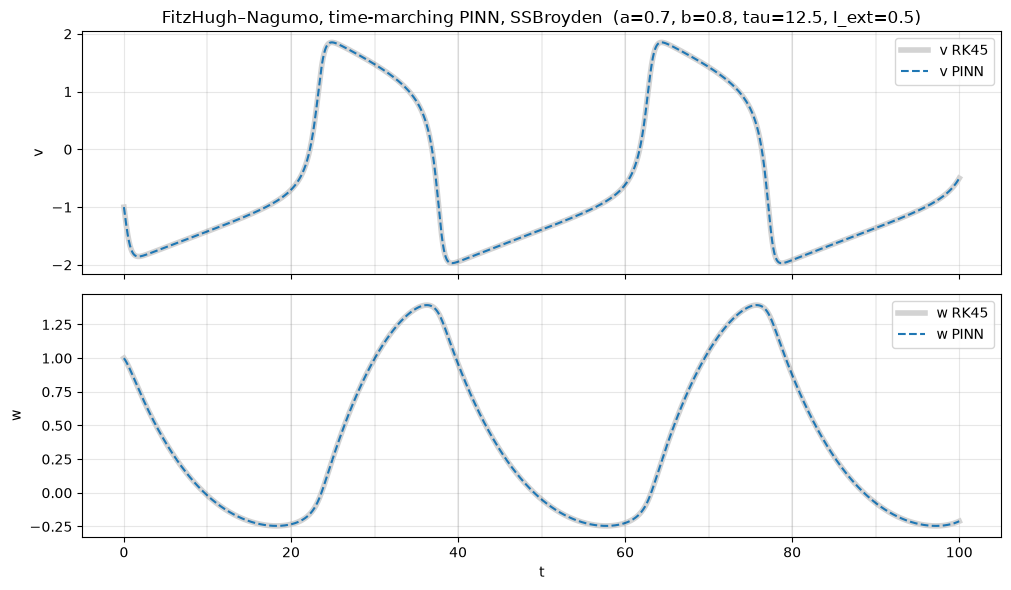

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for ax, pinn, ref, name in [(axes[0], v, v_ref, "v"), (axes[1], w, w_ref, "w")]:
    ax.plot(t, ref, color="lightgray", lw=4, label=f"{name} RK45")
    ax.plot(t, pinn, "--", lw=1.5, label=f"{name} PINN")
    for e in edges[1:-1]:
        ax.axvline(e, color="k", lw=0.3, alpha=0.3)
    ax.set_ylabel(name)
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)
axes[1].set_xlabel("t")
axes[0].set_title(f"FitzHugh–Nagumo, time-marching PINN, SSBroyden  (a={a}, b={b}, tau={tau}, I_ext={I_ext})")
plt.tight_layout()
plt.show()

## Pointwise error

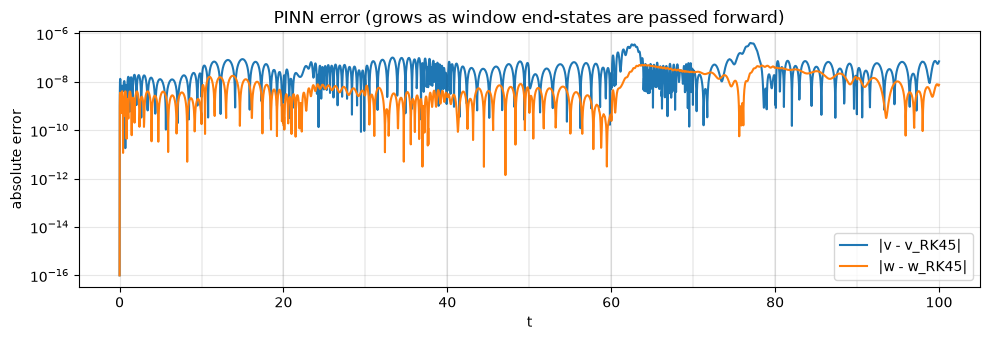

In [7]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.semilogy(t, err_v + 1e-16, label="|v - v_RK45|")
ax.semilogy(t, err_w + 1e-16, label="|w - w_RK45|")
for e in edges[1:-1]:
    ax.axvline(e, color="k", lw=0.3, alpha=0.3)
ax.set_xlabel("t")
ax.set_ylabel("absolute error")
ax.set_title("PINN error (grows as window end-states are passed forward)")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## Phase plane

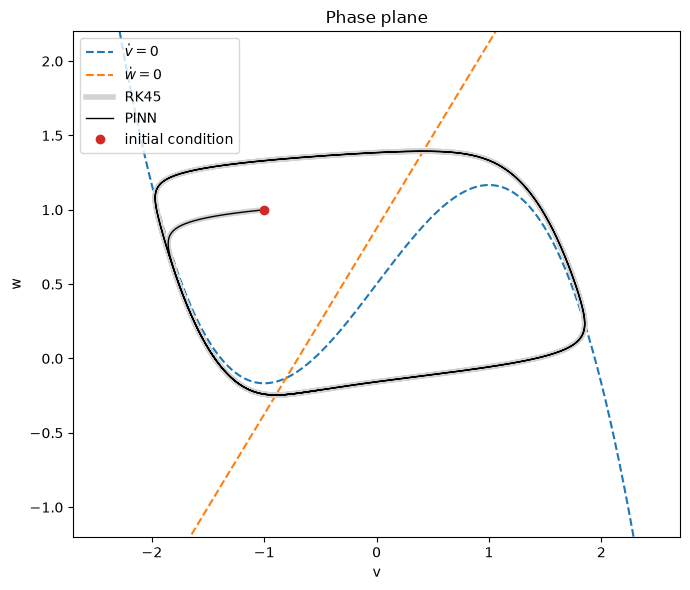

In [8]:
vv = np.linspace(-2.7, 2.7, 400)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(vv, vv - vv**3 / 3 + I_ext, "--", label=r"$\dot v = 0$")
ax.plot(vv, (vv + a) / b, "--", label=r"$\dot w = 0$")
ax.plot(v_ref, w_ref, color="lightgray", lw=4, label="RK45")
ax.plot(v, w, "k", lw=1.0, label="PINN")
ax.plot(v0, w0, "o", color="tab:red", label="initial condition")
ax.set_xlim(-2.7, 2.7)
ax.set_ylim(-1.2, 2.2)
ax.set_xlabel("v")
ax.set_ylabel("w")
ax.set_title("Phase plane")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Training history per window

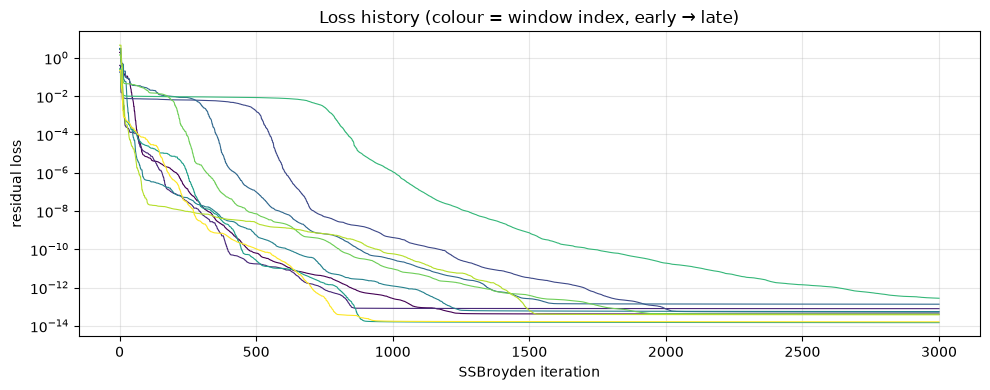

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
cmap = plt.get_cmap("viridis")
for k, history in enumerate(histories):
    ax.semilogy(history, color=cmap(k / max(len(histories) - 1, 1)), lw=0.8)
ax.set_xlabel("SSBroyden iteration")
ax.set_ylabel("residual loss")
ax.set_title("Loss history (colour = window index, early → late)")
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## Save results

In [10]:
np.savez("fitzhugh_nagumo_pinn_jax_marching_solution.npz",
         t=t, v=v, w=w, v_ref=v_ref, w_ref=w_ref, edges=edges)